In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.transforms import IdentityTransform
from matplotlib.legend_handler import HandlerPatch
from matplotlib.ticker import FormatStrFormatter  # oder FuncFormatter
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# Generelle Einstellungen zu den Plots
plt.rcParams.update({
  'font.size': 10,
  'lines.linewidth': 1.2,
  'axes.linewidth': 0.8,
})

print('Imports OK')

Imports OK


In [2]:
# Daten einfügen in dieser Reihenfolge!: (1D; 2D ref 90; 2D ref fit, 2D top 90; 2D top fit)
kategorien = [f"1D \n0,9 - 0,1 \nRef", f"2D \n0,9 \nRef", f"2D \nFit \nRef", f"2D \n0,9 \nTop", f"2D \nFit \nTop"]
mean = np.array([2.6e-3, 9.6e-3, 8.0e-3, 1.1e-2, 8.4e-3])
mean_log = np.array([2.2e-3, 7.6e-3, 6.3e-3, 9.1e-3, 6.9e-3])
std = np.array([1.6e-3, 5.9e-3, 6.0e-3, 6.5e-3, 5.9e-3])
std_log = np.array([0.25, 0.32, 0.30, 0.24, 0.27])


/var/folders/td/9tkrvkm13dj06nbfft00xzww0000gn/T/ipykernel_38157/252279843.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


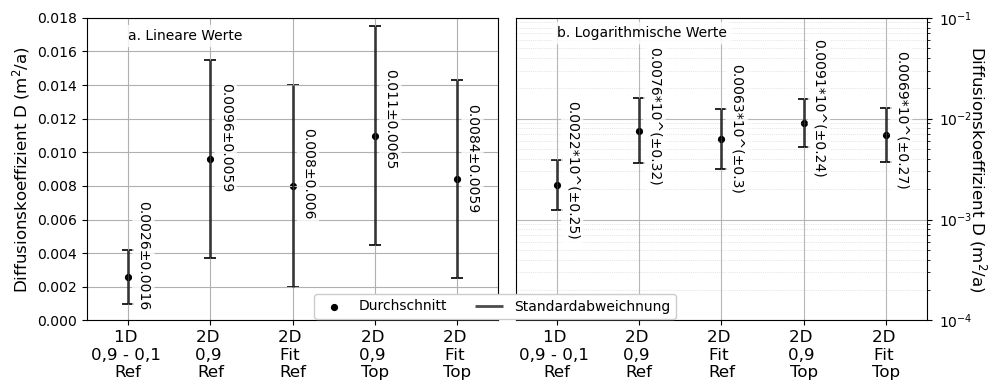

In [6]:
#Plot der Mittelwerte über die Gesamten Daten einer Einheit (Geologie, Vegetation...) 


fig, axes = plt.subplots(1,2, figsize=(10,4), sharex=True, sharey=False, constrained_layout=True)
ax0 = axes[0]
ax1 = axes[1]

x = np.arange(len(kategorien))
ax1.set_xticks(x)
ax1.set_xticklabels(kategorien, fontsize=12)
ax1.set_xlim(x[0] - 0.5, x[-1] + 0.5)

ax1.yaxis.set_label_position("right")
ax1.yaxis.tick_right()  
ax1.set_yscale('log', base=10)            # falls benötigt
ax1.set_ylabel(f"Diffusionskoeffizient D (m$^2$/a)", rotation=270, fontsize=12)
ax1.yaxis.set_label_coords(+1.15, 0.5) 
ax1.yaxis.set_tick_params(pad=5)
ax1.grid(True) 
ax1.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.9)
ax1.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.6)

ax1.set_yscale('log', base=10)
ax1.set_ylim(1e-4, 1e-1)

ax0.set_ylabel(f"Diffusionskoeffizient D (m$^2$/a)", color='k', fontsize=12)     # Beschriftung links
ax0.tick_params(axis='y', labelcolor='k')
ax0.set_ylim(0, 1.8e-2)
ax0.grid(True) 
ax0.set_xticklabels(kategorien, fontsize=12)
ax0.text(x[0], 0.0165, 'a. Lineare Werte', fontsize=10, va='bottom', ha='left', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.3'))

#Durschschnitt + Standartabweichung
ax0.scatter(x, mean, marker='.', color='k', s=70)
ax0.scatter(x, mean+std, marker='_', color='k', s=70)
ax0.scatter(x, mean-std, marker='_', color='k', s=70)

# senkrechte Linien (von y_min bis werte)
ax0.vlines(x, mean-std, mean+std, color='k', linestyle='-', linewidth=2, alpha=0.7)


# Optional: Werte als Text
for xi, yi, zi in zip(x, mean, std):
    ax0.text(xi+0.1, yi-0.002, f'{yi:.2g}±{zi:.2g}', ha='left', va='bottom', fontsize=10, rotation=270, bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.3'))

#Rechter subplot: Durschschnitt (Log10) + und Multiplikative Unsicherheit
ax1.scatter(x, mean_log, marker='.', color='k', s=70, label = 'Durchschnitt')
ax1.scatter(x, mean_log * 10**std_log, marker='_', color='k', s=70) #
ax1.scatter(x, mean_log * 10**(-std_log) , marker='_', color='k', s=70) #
ax1.vlines(x, mean_log * 10**std_log, mean_log * 10**(-std_log), color='k', linestyle='-', linewidth=2, alpha=0.7, label = 'Standardabweichnung')
ax1.text(x[0], 6e-2, 'b. Logarithmische Werte', fontsize=10, va='bottom', ha='left', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.3'))

# Optional: Werte als Text
for xi, yi, zi in zip(x, mean_log, std_log):
    ax1.text(xi+0.1, yi/3.5, f'{yi:.2g}*10^(±{zi:.2g})', ha='left', va='bottom', fontsize=10, rotation=270, bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.3'))


leg = fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.27), ncol=2,) #ax1.legend(loc='best', frameon=True, ) #
leg.get_frame().set_alpha(1.0)
plt.tight_layout()
plt.savefig("lin_vs_log_D.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# Daten aus einzelnen Kratern
std_log_aus_Krater = np.array([0.18, 0.26, 0.27, 0.16, 0.21]) # Durchschnitt der Multiplikativen Unsicherheiten innerhalb eines Kraters


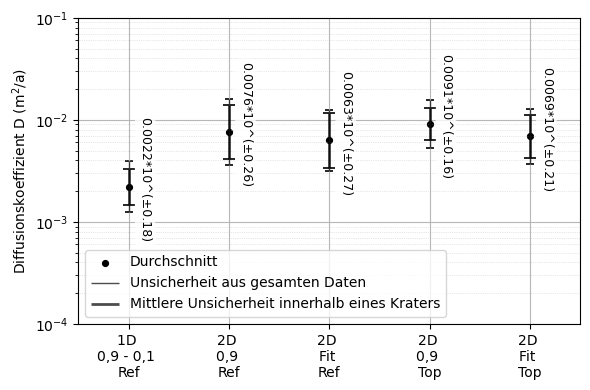

In [5]:
# Plot der Mittelwerte mit Durchschnittlichen Abweichungen innerhalb eines Kraters

fig2, ax = plt.subplots(figsize=(6,4))
ax.set_yscale('log', base=10)
ax.set_ylim(1e-4, 1e-1)
ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)

ax.set_xticks(x)
ax.set_xticks(x)
ax.set_xticklabels(kategorien)

ax.set_ylabel(f"Diffusionskoeffizient D (m$^2$/a)")

ax.grid(True) 
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.9)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.6)

#Werte Über gesamte Daten
plt.scatter(x, mean_log, marker='.', color='k', s=70, label = 'Durchschnitt')
plt.scatter(x, mean_log * 10**std_log, marker='_', color='k', s=40) #
plt.scatter(x, mean_log * 10**(-std_log) , marker='_', color='k', s=40) #
plt.vlines(x, mean_log * 10**std_log, mean_log * 10**(-std_log), color='k', linestyle='-', linewidth=1, alpha=0.7, label = 'Unsicherheit aus gesamten Daten')

#Mittelwerte für einzelne Krater
plt.scatter(x, mean_log * 10**std_log_aus_Krater, marker='_', color='k', s=70) #
plt.scatter(x, mean_log * 10**(-std_log_aus_Krater) , marker='_', color='k', s=70) #
plt.vlines(x, mean_log * 10**std_log_aus_Krater, mean_log * 10**(-std_log_aus_Krater), color='k', linestyle='-', linewidth=2, alpha=0.7, label = 'Mittlere Unsicherheit innerhalb eines Kraters')

# Optional: Werte als Text
for xi, yi, zi in zip(x, mean_log, std_log_aus_Krater):
    plt.text(xi+0.1, yi/3.5, f'{yi:.2g}*10^(±{zi:.2g})', ha='left', va='bottom', fontsize=9, rotation=270, bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.3'))

ax.legend(loc='best', frameon=True, )
plt.tight_layout()
plt.savefig("log_einzelner_Krater.pdf", dpi=300, bbox_inches="tight")
plt.show()